## <font size=5> <strong>  Problem Definition and Data Collection

Objective: Classify iris flowers into three species (setosa, versicolor, virginica) based on sepal and petal measurements

Input Features: sepal_length, sepal_width, petal_length, petal_width

Target Variable: species (multi-class classification)

## <font size=5> <strong>  Import Required Libraries

In [1]:
# Data manipulation and analysis
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('IRIS.csv')

 ## <font size=5> <strong> Exploratory Data Analysis (EDA)

In [2]:
# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
print("\nClass Distribution:")
print(df['species'].value_counts())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check for duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (150, 5)

First 5 rows:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Statistical Summary:
       sepal_length  sepal_width  petal_length  

## <font size=5> <strong> Data Visualization

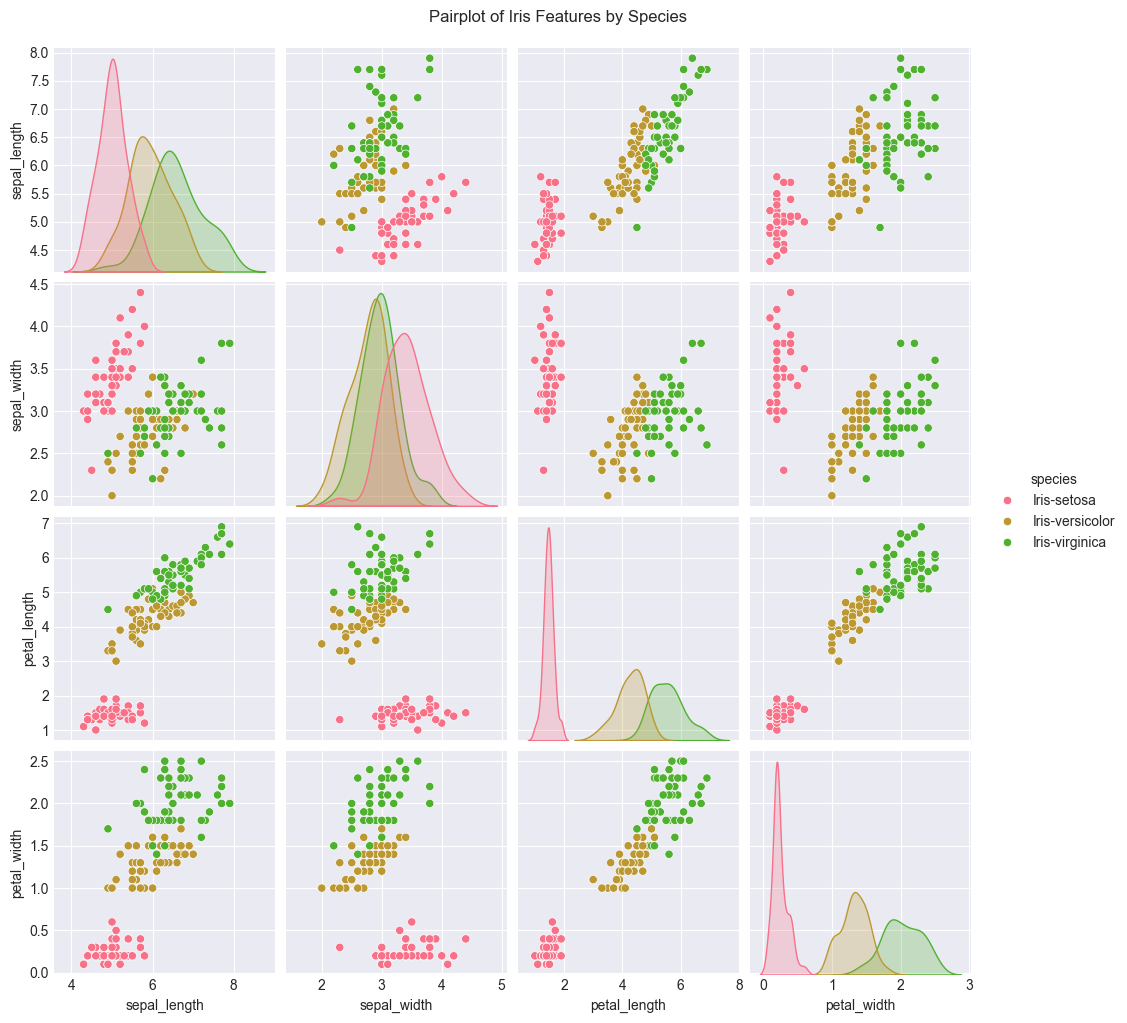

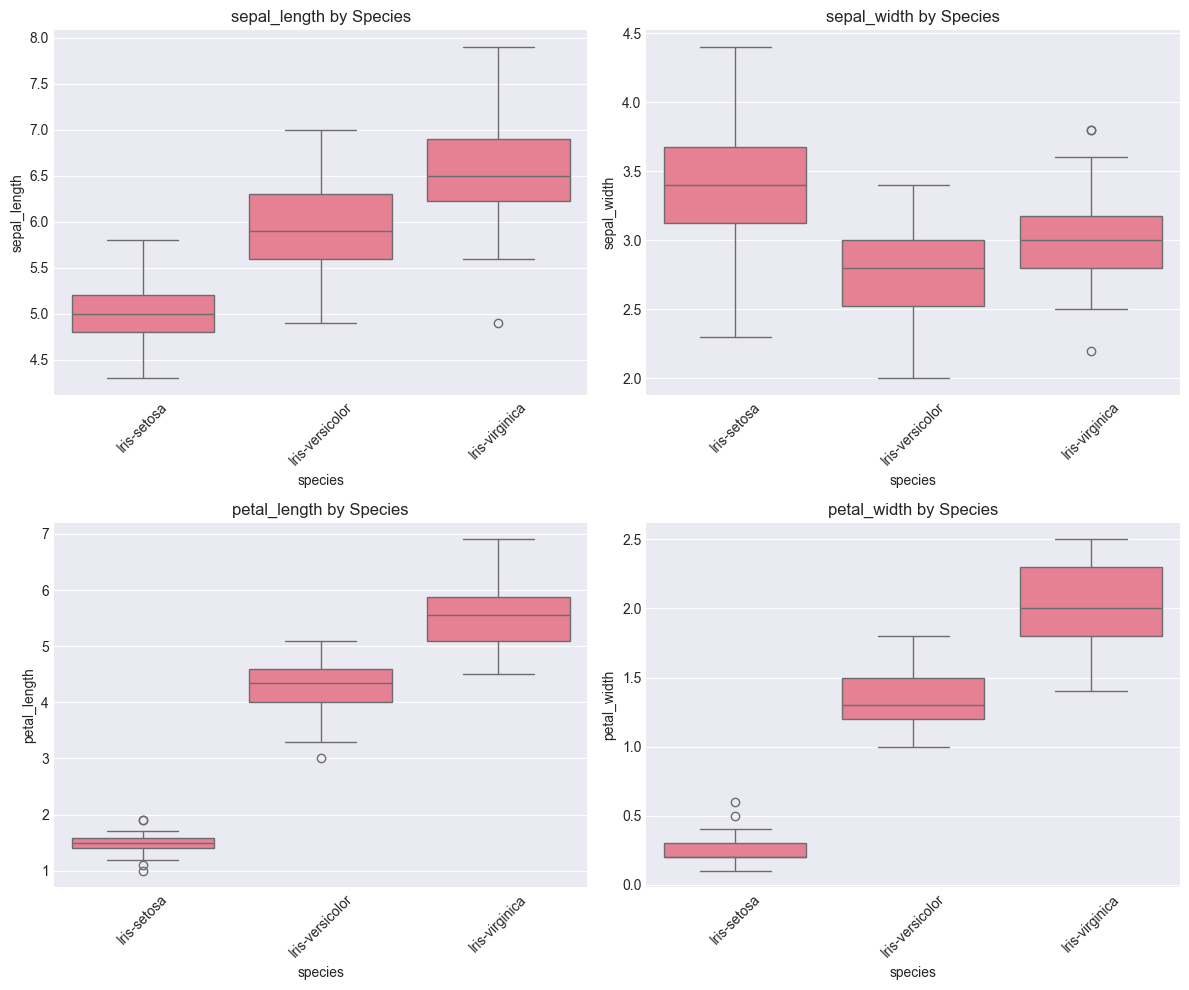

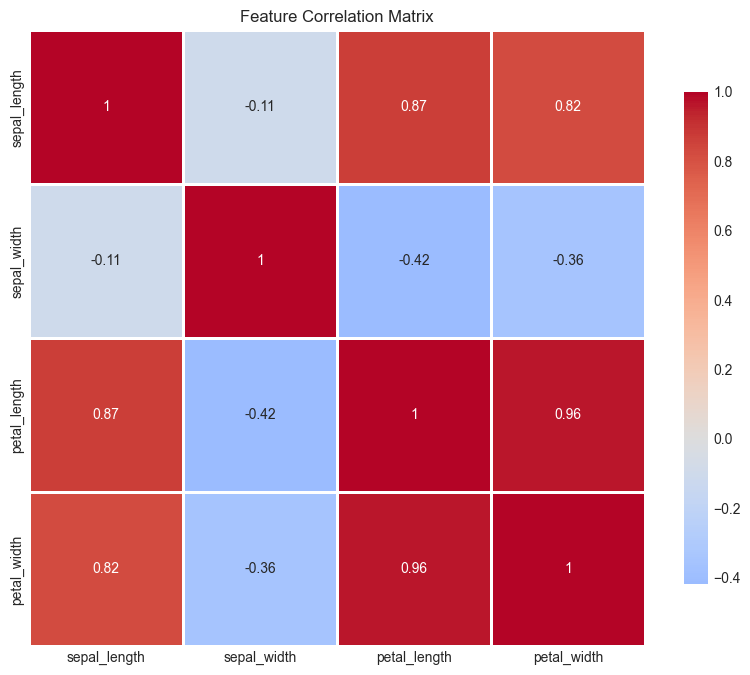

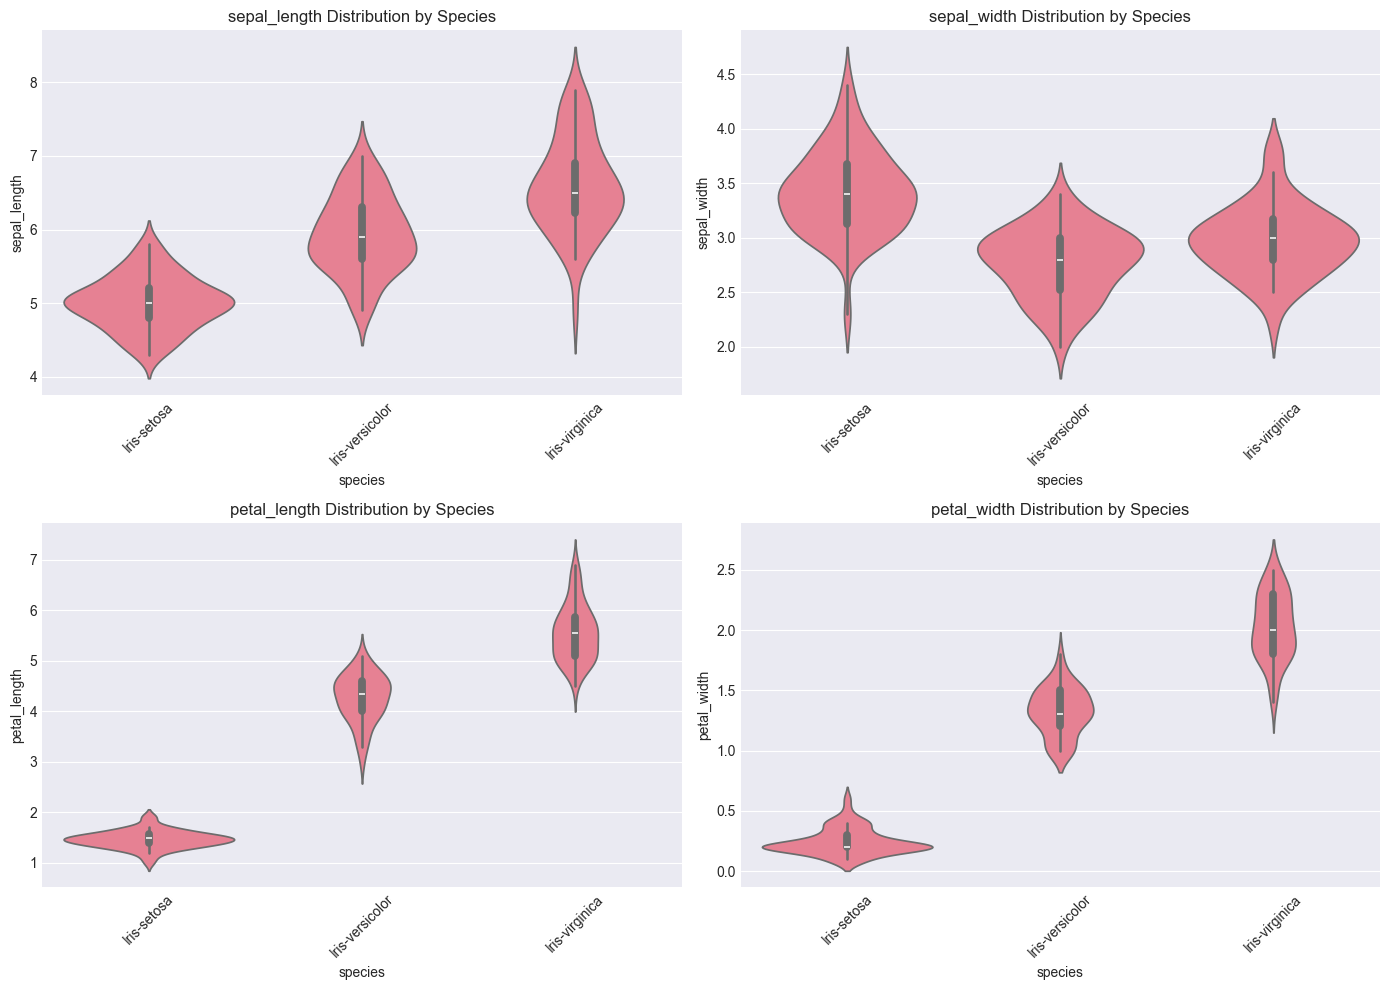

In [3]:
# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 1. Pairplot to visualize relationships between features
sns.pairplot(df, hue='species', height=2.5)
plt.suptitle('Pairplot of Iris Features by Species', y=1.02)
plt.show()

# 2. Box plots for each feature by species
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    sns.boxplot(x='species', y=feature, data=df, ax=axes[row, col])
    axes[row, col].set_title(f'{feature} by Species')
    axes[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 3. Correlation heatmap
plt.figure(figsize=(10, 8))
numeric_df = df.drop('species', axis=1)
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix')
plt.show()

# 4. Violin plots for distribution analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    sns.violinplot(x='species', y=feature, data=df, ax=axes[row, col])
    axes[row, col].set_title(f'{feature} Distribution by Species')
    axes[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## <font size=5> <strong>Data Preprocessing 

In [4]:
# Encode the target variable
label_encoder = LabelEncoder()
df['species_encoded'] = label_encoder.fit_transform(df['species'])
# 0: setosa, 1: versicolor, 2: virginica

print("Species encoding:")
for i, species in enumerate(label_encoder.classes_):
    print(f"{i}: {species}")

# Separate features and target
X = df.drop(['species', 'species_encoded'], axis=1)
y = df['species_encoded']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"\nTraining set class distribution:\n{y_train.value_counts().sort_index()}")
print(f"\nTesting set class distribution:\n{y_test.value_counts().sort_index()}")

# Feature scaling (important for many algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Species encoding:
0: Iris-setosa
1: Iris-versicolor
2: Iris-virginica

Training set size: (120, 4)
Testing set size: (30, 4)

Training set class distribution:
species_encoded
0    40
1    40
2    40
Name: count, dtype: int64

Testing set class distribution:
species_encoded
0    10
1    10
2    10
Name: count, dtype: int64


## <font size=5> <strong> Model Development and Training

In [5]:
# Define models to evaluate
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Train and evaluate each model
results = {}
predictions = {}

print("Model Performance:")
print("-" * 60)

for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    # Calculate accuracies
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    
    # Perform cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    
    # Store results
    results[name] = {
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    predictions[name] = y_pred_test
    
    print(f"\n{name}:")
    print(f"  Train Accuracy: {train_accuracy:.4f}")
    print(f"  Test Accuracy: {test_accuracy:.4f}")
    print(f"  CV Score (5-fold): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Model Performance:
------------------------------------------------------------

Logistic Regression:
  Train Accuracy: 0.9583
  Test Accuracy: 0.9333
  CV Score (5-fold): 0.9583 (+/- 0.0264)

K-Nearest Neighbors:
  Train Accuracy: 0.9750
  Test Accuracy: 0.9333
  CV Score (5-fold): 0.9667 (+/- 0.0312)

Decision Tree:
  Train Accuracy: 1.0000
  Test Accuracy: 0.9000
  CV Score (5-fold): 0.9417 (+/- 0.0204)

Random Forest:
  Train Accuracy: 1.0000
  Test Accuracy: 0.9000
  CV Score (5-fold): 0.9500 (+/- 0.0167)

SVM:
  Train Accuracy: 0.9750
  Test Accuracy: 0.9667
  CV Score (5-fold): 0.9667 (+/- 0.0312)

Gradient Boosting:
  Train Accuracy: 1.0000
  Test Accuracy: 0.9000
  CV Score (5-fold): 0.9667 (+/- 0.0167)


## <font size=5> <strong> Model Evaluation and Comparison


Model Comparison:
                     train_accuracy  test_accuracy   cv_mean    cv_std
SVM                        0.975000       0.966667  0.966667  0.031180
Logistic Regression        0.958333       0.933333  0.958333  0.026352
K-Nearest Neighbors        0.975000       0.933333  0.966667  0.031180
Decision Tree              1.000000       0.900000  0.941667  0.020412
Random Forest              1.000000       0.900000  0.950000  0.016667
Gradient Boosting          1.000000       0.900000  0.966667  0.016667


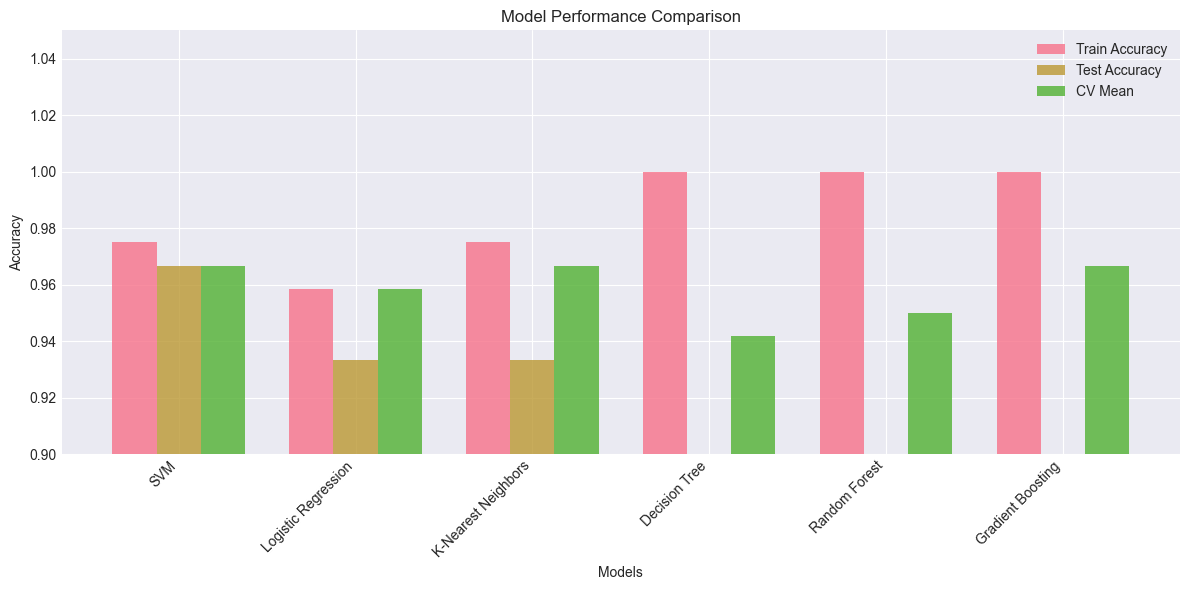

In [6]:
# Create comparison dataframe
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('test_accuracy', ascending=False)
print("\nModel Comparison:")
print(results_df)

# Visualize model comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(results_df))
width = 0.25

ax.bar([i - width for i in x], results_df['train_accuracy'], width, label='Train Accuracy', alpha=0.8)
ax.bar(x, results_df['test_accuracy'], width, label='Test Accuracy', alpha=0.8)
ax.bar([i + width for i in x], results_df['cv_mean'], width, label='CV Mean', alpha=0.8)

ax.set_xlabel('Models')
ax.set_ylabel('Accuracy')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0.9, 1.05)
plt.tight_layout()
plt.show()

## <font size=5> <strong> Hyperparameter Tuning for Best Model

In [7]:
# Based on initial results, let's tune the best performing models

# 1. Random Forest Tuning
print("\n=== Random Forest Hyperparameter Tuning ===")
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
rf_grid_search.fit(X_train_scaled, y_train)

print(f"Best Random Forest Parameters: {rf_grid_search.best_params_}")
print(f"Best Random Forest CV Score: {rf_grid_search.best_score_:.4f}")

# 2. SVM Tuning
print("\n=== SVM Hyperparameter Tuning ===")
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.1, 0.01, 0.001, 'scale', 'auto'],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

svm_grid_search = GridSearchCV(
    SVC(random_state=42),
    svm_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
svm_grid_search.fit(X_train_scaled, y_train)

print(f"Best SVM Parameters: {svm_grid_search.best_params_}")
print(f"Best SVM CV Score: {svm_grid_search.best_score_:.4f}")

# Use the best model (likely Random Forest or SVM)
best_model = rf_grid_search.best_estimator_
if svm_grid_search.best_score_ > rf_grid_search.best_score_:
    best_model = svm_grid_search.best_estimator_


=== Random Forest Hyperparameter Tuning ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Random Forest Parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best Random Forest CV Score: 0.9667

=== SVM Hyperparameter Tuning ===
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best SVM Parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Best SVM CV Score: 0.9833


## <font size=5> <strong>  Final Model Evaluation


=== Final Model Performance ===
Model Type: SVC

Accuracy: 0.9667

Precision (macro): 0.9697
Recall (macro): 0.9667
F1-Score (macro): 0.9666

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



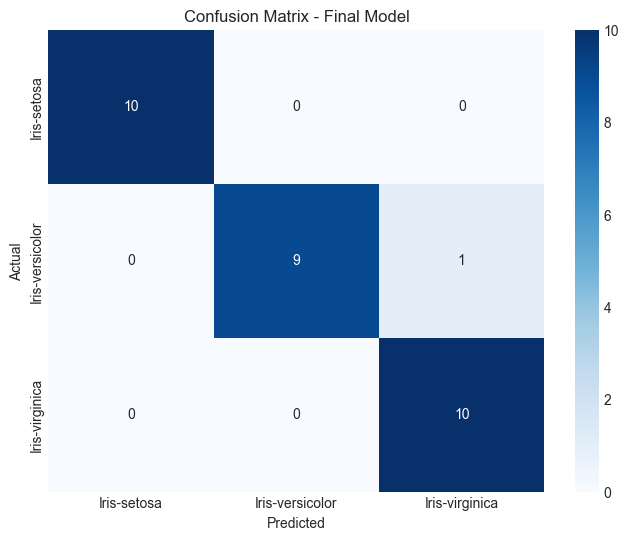

In [8]:
# Make predictions with the best model
y_pred_final = best_model.predict(X_test_scaled)

# Calculate comprehensive metrics
print("\n=== Final Model Performance ===")
print(f"Model Type: {type(best_model).__name__}")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"\nPrecision (macro): {precision_score(y_test, y_pred_final, average='macro'):.4f}")
print(f"Recall (macro): {recall_score(y_test, y_pred_final, average='macro'):.4f}")
print(f"F1-Score (macro): {f1_score(y_test, y_pred_final, average='macro'):.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, 
                           target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Final Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importance (if applicable)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(8, 5))
    sns.barplot(x='importance', y='feature', data=feature_importance)
    plt.title('Feature Importance - Random Forest')
    plt.tight_layout()
    plt.show()

## <font size=5> <strong>  Model Interpretation and Insights

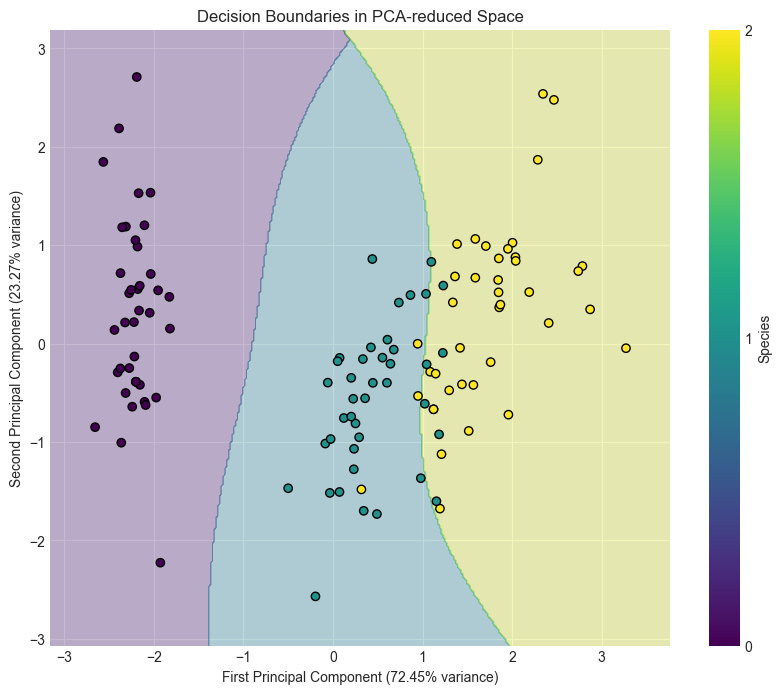

In [9]:
# Decision Boundaries Visualization (using 2 PCA components for visualization)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train a simple model on PCA components for visualization
viz_model = SVC(kernel='rbf', random_state=42)
viz_model.fit(X_train_pca, y_train)

# Create mesh for decision boundary
x_min, x_max = X_train_pca[:, 0].min() - 0.5, X_train_pca[:, 0].max() + 0.5
y_min, y_max = X_train_pca[:, 1].min() - 0.5, X_train_pca[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Plot decision boundary
Z = viz_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                      c=y_train, cmap='viridis', edgecolors='black')
plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Decision Boundaries in PCA-reduced Space')
plt.colorbar(scatter, ticks=[0, 1, 2], label='Species')
plt.show()

## <font size=5> <strong>   Final Recommendations

In [10]:
# Production-ready code for the best model
def create_iris_classifier():
    """
    Creates and returns the best performing model for Iris classification
    """
    # Load and preprocess data
    df = pd.read_csv('IRIS.csv')
    X = df.drop('species', axis=1)
    y = df['species']
    
    # Encode labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Train Random Forest (recommended)
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=5,
        random_state=42
    )
    
    # Train on entire dataset for production
    model.fit(X_scaled, y_encoded)
    
    return model, scaler, le

# Example prediction function
def predict_species(measurements, model, scaler, le):
    """
    Predict iris species from measurements
    measurements: [sepal_length, sepal_width, petal_length, petal_width]
    """
    scaled_measurements = scaler.transform([measurements])
    prediction_encoded = model.predict(scaled_measurements)
    return le.inverse_transform(prediction_encoded)[0]

# Example usage
# model, scaler, le = create_iris_classifier()
# species = predict_species([5.1, 3.5, 1.4, 0.2], model, scaler, le)
# print(f"Predicted species: {species}")